# Sutura — quick inference

Register a **moving** slice **B** onto a **reference** slice **A**: for every
spot in B, predict its coordinate in A's frame. This notebook runs the
pretrained checkpoint end-to-end on a spatialLIBD DLPFC slice pair (CPU, < 1 min).

Run from the repo root or from `examples/` — the first cell fixes the path.


In [1]:
%matplotlib inline
import os, sys
# make the repo root importable whether run from repo root or examples/
ROOT = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'examples' else os.path.abspath('.')
sys.path.insert(0, ROOT)
import numpy as np, torch, anndata as ad
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt

from model import load_checkpoint
from train import fit_shared_basis, graph_tensors
from metrics import registration_error_stats
from model.contrastive import partner_index
print('repo root:', ROOT)

C:\Users\karti\arca\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


repo root: C:\Users\karti\sutura-paper-release


## 0. Get the data

The spatialLIBD slices (Figshare 22004273) are not shipped in the repo. The
cell below downloads the two sections we need into `data/` if they're absent
(one-time, ~a few MB each).


In [2]:
data_dir = os.path.join(ROOT, 'data')
ref_id, mov_id = '151507', '151508'   # adjacent sections, donor Br8100
need = [s for s in (ref_id, mov_id)
        if not os.path.exists(os.path.join(data_dir, f'DLPFC_{s}.h5ad'))]
if need:
    from data.load_spatiallibd import prepare
    prepare(need)   # downloads + standardizes into data/
else:
    print('data already present')

data already present


## 1. Load the pretrained checkpoint

`load_checkpoint` rebuilds the model with the saved hyperparameters and loads
the weights (the helper remaps legacy attention keys). It returns the model
(already in `.eval()` mode) and the checkpoint dict.


In [3]:
ckpt_path = os.path.join(ROOT, 'checkpoints', 'sutura_insample.pt')
model, ckpt = load_checkpoint(ckpt_path)
knn     = ckpt['args'].get('knn', 6)
pca_dim = ckpt['args'].get('pca_dim', 50)
n_params = sum(p.numel() for p in model.parameters())
print(f'loaded {ckpt_path}')
print(f'params={n_params:,}  knn={knn}  pca_dim={pca_dim}')

loaded C:\Users\karti\sutura-paper-release\checkpoints\sutura_insample.pt
params=74,178  knn=6  pca_dim=50


## 2. Load a pair of slices

Inputs are two `AnnData` objects with the same gene set, raw/normalized counts
in `.X`, and pixel coordinates in `.obsm["spatial"]`. We use the **full**
slices (inference is < 1 s on CPU); subsampling is intentionally avoided here —
it would break the kNN spatial graph the model relies on. `array_row`/
`array_col` provide the optional array-bridge ground truth.


In [4]:
A = ad.read_h5ad(os.path.join(data_dir, f'DLPFC_{ref_id}.h5ad'))   # reference
B = ad.read_h5ad(os.path.join(data_dir, f'DLPFC_{mov_id}.h5ad'))   # moving
a_coords = np.asarray(A.obsm['spatial'], np.float32)
b_coords = np.asarray(B.obsm['spatial'], np.float32)
pitch = float(np.median(cKDTree(a_coords).query(a_coords, k=2)[0][:, 1]))
print(f'A spots={A.n_obs}  B spots={B.n_obs}  pitch={pitch:.1f}px')

A spots=4226  B spots=4384  pitch=137.0px


## 3. Build features and graphs

`fit_shared_basis` fits one TruncatedSVD basis on the pair's log-normalized
expression and returns a projector. Use the feature mode the checkpoint was
trained with (shipped checkpoints are `global`; batch-robust cross-donor models
trained with `--feature-mode perslice` use `perslice`). `graph_tensors` builds
each slice's kNN spatial graph with pitch-normalized relative-position edges.


In [5]:
feat_mode = ckpt['args'].get('feature_mode') or 'global'   # shipped ckpts: global
project = fit_shared_basis([A, B], pca_dim, seed=0, feature_mode=feat_mode)
ga = graph_tensors(a_coords, project(A), knn, pitch)
gb = graph_tensors(b_coords, project(B), knn, pitch)
a_norm = torch.from_numpy(a_coords / pitch)   # A coords in pitch units
print('feature dim:', ga['x'].shape[1], ' A graph edges:', ga['edge_index'].shape[1])

feature dim: 50  A graph edges: 50712


## 4. Inference

The model maps each B spot to A's frame (output is in pitch units; multiply by
`pitch` to get pixels).


In [6]:
with torch.no_grad():
    pred_A = model(ga, gb, a_norm).numpy() * pitch   # (n_B, 2) pixels in A's frame
print('pred_A shape:', pred_A.shape)
print('first 3 predicted A-frame coords (px):')
print(pred_A[:3])

pred_A shape: (4384, 2)
first 3 predicted A-frame coords (px):
[[9351.598  3209.2607]
 [5091.3906 8818.869 ]
 [3525.4536 2225.3545]]


## 5. Interpret and score the output

`pred_A[i]` is the predicted reference-frame pixel coordinate of moving-slice
spot `i` (in B's spot order). With the array bridge we can score it: each B spot
has a known A partner at the same Visium array position.


In [7]:
p = partner_index(A, B)                 # B->A index (-1 if none)
have = p >= 0
gt = np.full((B.n_obs, 2), np.nan, np.float32)
gt[have] = a_coords[p[have]]
stats = registration_error_stats(pred_A, gt, mask=have)
print('registration error (px):', {k: round(v, 1) if isinstance(v, float) else v
                                    for k, v in stats.items()})

registration error (px): {'mean': 106.9, 'median': 96.2, 'p90': 181.9, 'max': 765.1, 'n': 4182}


### Visualize

Reference A (gray), B's raw coordinates (orange), and B mapped into A's frame by
Sutura (blue). Good registration pulls the blue points onto the gray cloud.


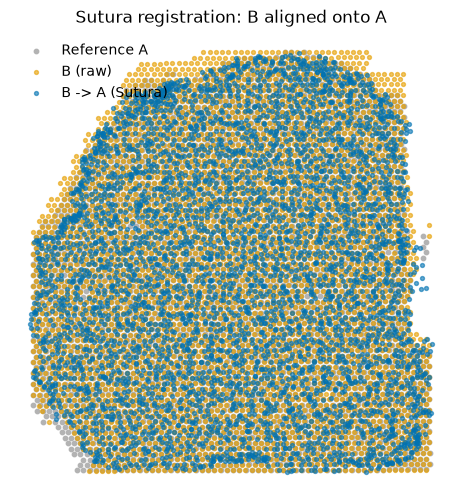

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(a_coords[:, 0], a_coords[:, 1], s=10, c='0.7', label='Reference A')
ax.scatter(b_coords[:, 0], b_coords[:, 1], s=8, c='#E69F00', alpha=0.6, label='B (raw)')
ax.scatter(pred_A[:, 0], pred_A[:, 1], s=8, c='#0072B2', alpha=0.6, label='B -> A (Sutura)')
ax.set_aspect('equal'); ax.invert_yaxis(); ax.legend(frameon=False)
ax.set_title('Sutura registration: B aligned onto A'); ax.axis('off')
plt.show()

## Output format recap

- **`pred_A`** — `numpy.ndarray` `(n_B, 2)`, predicted **reference-frame pixel
  coordinates**, one row per moving-slice spot, in B's spot order.
- To register B, set `B.obsm['spatial'] = pred_A`. Errors are in pixels
  (1 spot pitch ≈ 137 px here).

**Note:** `sutura_insample.pt` was trained on the 151507/151508 pair, so it is
most accurate there; on an unseen donor expect larger error (the open
cross-donor generalization problem characterized in the paper).
